In [1]:
!pip install umap-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 1.2 MB/s eta 0:00:00


In [4]:
# Importar las librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.datasets import fetch_openml
import umap
from tensorflow.keras.datasets import mnist


# Cargar el conjunto de datos MNIST desde Keras
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Aplanar las imágenes de 28x28 a vectores de 784 dimensiones
X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

# Tomar una muestra de los datos para hacer la optimización más rápida
sample_size = 1000  # Ajusta este valor si deseas cambiar el tamaño de la muestra
X_train, y_train = X_train[:sample_size], y_train[:sample_size]
X_test, y_test = X_test[:sample_size], y_test[:sample_size]


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


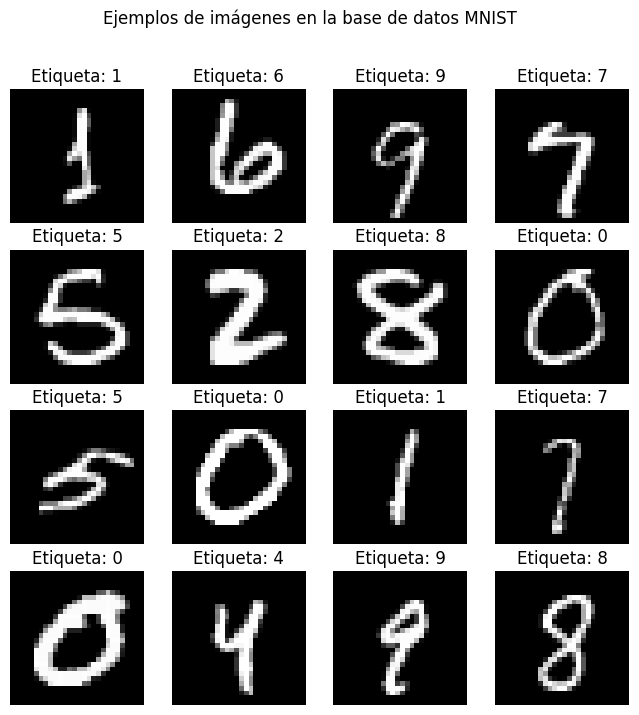

In [5]:
def plot_mnist_samples(X, y, num_images=16):
    plt.figure(figsize=(8, 8))
    indices = np.random.choice(range(len(X)), num_images, replace=False)
    for i, idx in enumerate(indices):
        plt.subplot(4, 4, i + 1)
        plt.imshow(X[idx].reshape(28, 28), cmap='gray')
        plt.title(f"Etiqueta: {y[idx]}")
        plt.axis('off')
    plt.suptitle("Ejemplos de imágenes en la base de datos MNIST")
    plt.show()

# Mostrar algunas imágenes de ejemplo de MNIST
plot_mnist_samples(X_test, y_test)

In [6]:

# Función para visualizar los resultados de reducción de dimensionalidad
def plot_embedding(X_embedded, title, labels):
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=labels, cmap='tab10', alpha=0.7)
    plt.colorbar(scatter, ticks=range(10))
    plt.title(title)
    plt.xlabel("Componente 1")
    plt.ylabel("Componente 2")
    plt.show()




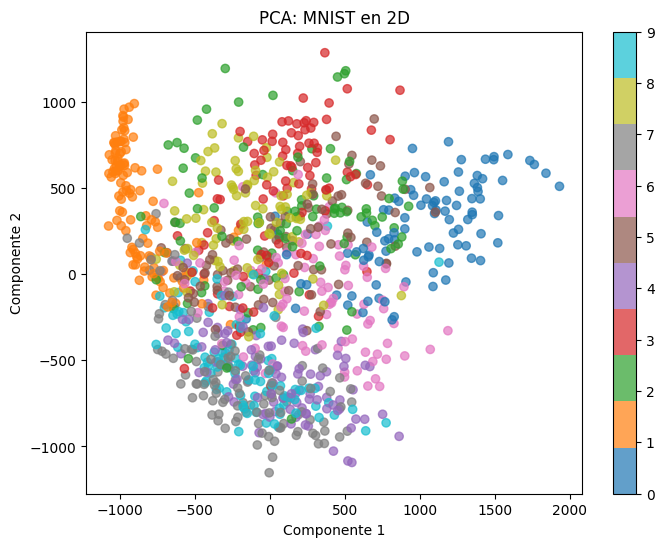

/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


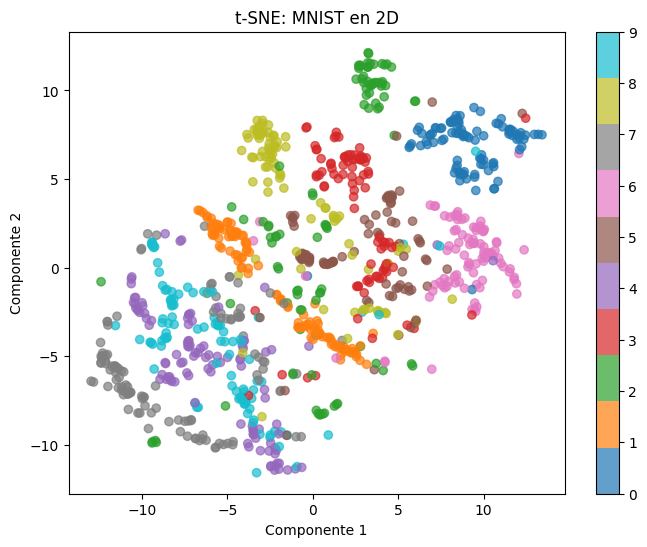

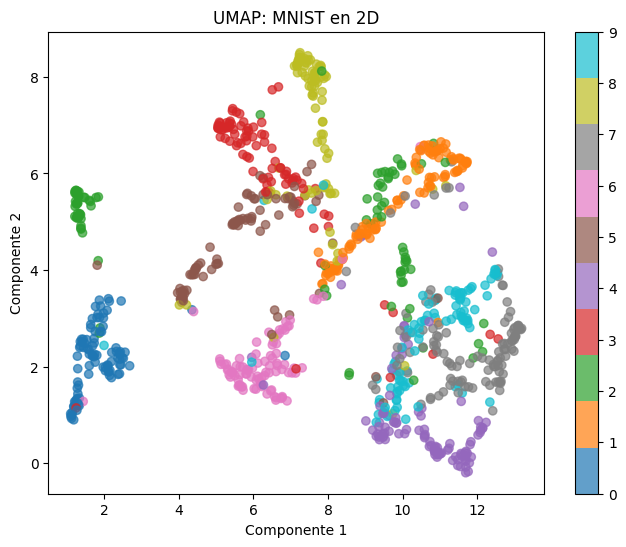

In [7]:
# Reducción de dimensionalidad con PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)
plot_embedding(X_pca, "PCA: MNIST en 2D", y_train)

# Reducción de dimensionalidad con t-SNE
tsne = TSNE(n_components=2, perplexity=30, n_iter=300)
X_tsne = tsne.fit_transform(X_train)
plot_embedding(X_tsne, "t-SNE: MNIST en 2D", y_train)

# Reducción de dimensionalidad con UMAP
umap_model = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, metric='euclidean')
X_umap = umap_model.fit_transform(X_train)
plot_embedding(X_umap, "UMAP: MNIST en 2D", y_train)

# Lista de los hiperparámetros más importantes para **PCA**, **t-SNE** y **UMAP**

### 1. PCA (Principal Component Analysis)

PCA es un método lineal de reducción de dimensionalidad y tiene pocos hiperparámetros importantes:

- **n_components**:
  - **Descripción**: Número de componentes principales que se desean conservar.
  - **Valores comunes**: Un número entero (e.g., `2` para visualización en 2D) o un valor decimal entre 0 y 1 que indica el porcentaje de varianza explicada (e.g., `0.95` para conservar el 95% de la varianza).
  
- **whiten**:
  - **Descripción**: Si se activa, los componentes se escalan para que tengan varianza unitaria.
  - **Valores comunes**: `True` o `False` (por defecto es `False`). Utilizar `True` puede ser útil cuando se desea normalizar los datos para ciertos algoritmos de machine learning.

- **svd_solver**:
  - **Descripción**: Define el algoritmo para calcular la descomposición de valores singulares.
  - **Valores comunes**: `'auto'`, `'full'`, `'arpack'`, `'randomized'`. El valor `'auto'` elige el algoritmo de acuerdo con el tamaño y los valores de `n_components`.



### 2. t-SNE (t-Distributed Stochastic Neighbor Embedding)

t-SNE es un método no lineal que se usa para la visualización, y sus hiperparámetros son más sensibles y pueden afectar notablemente el resultado final.

- **n_components**:
  - **Descripción**: Número de dimensiones del espacio embebido.
  - **Valores comunes**: `2` (para visualización en 2D) o `3` (para visualización en 3D).

- **perplexity**:
  - **Descripción**: Controla el balance entre las relaciones locales y globales. Es una medida de "vecindad" en el espacio de alta dimensión.
  - **Valores comunes**: Entre `5` y `50`. Valores bajos hacen que t-SNE se enfoque en relaciones muy locales, mientras que valores más altos capturan relaciones más globales. `30` es un valor comúnmente usado.

- **learning_rate (o early_exaggeration)**:
  - **Descripción**: Controla la magnitud del movimiento de los puntos en el espacio embebido durante el aprendizaje.
  - **Valores comunes**: Entre `10` y `1000`. Un valor común es `200`. Si el resultado es muy difuso, puede ser útil reducir este valor.

- **n_iter**:
  - **Descripción**: Número de iteraciones de optimización.
  - **Valores comunes**: `250` a `1000` iteraciones suelen ser suficientes. Si el resultado no converge, se puede aumentar este valor.

- **metric**:
  - **Descripción**: La métrica de distancia utilizada para calcular la similitud entre puntos.
  - **Valores comunes**: `'euclidean'` (por defecto) u otras métricas como `'cosine'`, `'manhattan'`, etc. Cambiar la métrica puede ser útil dependiendo del tipo de datos.



### 3. UMAP (Uniform Manifold Approximation and Projection)

UMAP es otra técnica no lineal y tiene varios hiperparámetros clave que afectan tanto la velocidad como la precisión de la proyección.

- **n_neighbors**:
  - **Descripción**: Controla el número de vecinos considerados para determinar la estructura local de los datos.
  - **Valores comunes**: Entre `5` y `50`. Valores bajos hacen que UMAP se enfoque en relaciones muy locales, mientras que valores más altos capturan una estructura global más amplia. Un valor común es `15`.

- **n_components**:
  - **Descripción**: Número de dimensiones en el espacio embebido.
  - **Valores comunes**: `2` o `3`, típicamente para visualización, pero puede ser mayor en casos específicos.

- **min_dist**:
  - **Descripción**: Define la distancia mínima permitida entre puntos en el espacio embebido, controlando la dispersión de los puntos.
  - **Valores comunes**: Entre `0.0` y `0.99`. Valores bajos (e.g., `0.1`) tienden a crear agrupamientos más compactos, mientras que valores altos (`0.5` o más) permiten una proyección más dispersa.

- **metric**:
  - **Descripción**: Métrica utilizada para calcular la distancia en el espacio de alta dimensión.
  - **Valores comunes**: `'euclidean'` (por defecto) o métricas alternativas como `'cosine'`, `'manhattan'`, y `'correlation'`. Dependiendo de los datos, una métrica diferente puede mejorar los resultados.

- **spread**:
  - **Descripción**: Controla la dispersión de los puntos en el espacio embebido y, junto con `min_dist`, define la densidad de los grupos de puntos.
  - **Valores comunes**: Entre `0.5` y `1.5`. Un valor común es `1.0`.

- **set_op_mix_ratio**:
  - **Descripción**: Controla el balance entre relaciones de vecindad local y global.
  - **Valores comunes**: Entre `0` y `1`. Un valor de `1` utiliza solo relaciones locales, mientras que `0` mezcla las relaciones locales y globales.

- **target_weight**:
  - **Descripción**: Controla la influencia de las etiquetas de clase en el modelo (solo se usa en UMAP supervisado).
  - **Valores comunes**: Entre `0.0` y `1.0`. Un valor de `0.5` es común en escenarios supervisados.


In [8]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 362.8/362.8 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.2/233.2 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 6.0 MB/s eta 0:00:00


In [16]:
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import optuna

# 1. Función objetivo para PCA usando varianza explicada acumulada
def objective_pca(trial):
    n_components = trial.suggest_int("n_components", 2, 50)

    # Aplicar PCA
    pca = PCA(n_components=n_components)
    X_embedded = pca.fit_transform(X_train)

    # Maximizar la varianza explicada
    explained_variance = np.sum(pca.explained_variance_ratio_)
    return explained_variance

# 2. Función objetivo para t-SNE usando Silhouette Score
def objective_tsne(trial):
    n_components = trial.suggest_int("n_components", 2, 3)
    perplexity = trial.suggest_int("perplexity", 5, 50)
    learning_rate = trial.suggest_float("learning_rate", 10, 1000, log=True)
    n_iter = trial.suggest_int("n_iter", 250, 1000)

    # Aplicar t-SNE
    tsne = TSNE(n_components=n_components, perplexity=perplexity, learning_rate=learning_rate, n_iter=n_iter)
    X_embedded = tsne.fit_transform(X_train)

    # Calcular Silhouette Score
    score = silhouette_score(X_embedded, y_train)
    return score

# 3. Función objetivo para UMAP usando Silhouette Score
def objective_umap(trial):
    n_components = trial.suggest_int("n_components", 2, 3)
    n_neighbors = trial.suggest_int("n_neighbors", 5, 50)
    min_dist = trial.suggest_float("min_dist", 0.0, 0.99)

    # Aplicar UMAP
    umap_model = umap.UMAP(n_components=n_components, n_neighbors=n_neighbors, min_dist=min_dist)
    X_embedded = umap_model.fit_transform(X_train)

    # Calcular Silhouette Score
    score = silhouette_score(X_embedded, y_train)
    return score

# Crear y optimizar estudios individuales para cada método
# Optimización de PCA
study_pca = optuna.create_study(direction="maximize")
study_pca.optimize(objective_pca, n_trials=20)
print("Best hyperparameters for PCA:", study_pca.best_params)

# Optimización de t-SNE
study_tsne = optuna.create_study(direction="maximize")
study_tsne.optimize(objective_tsne, n_trials=20)
print("Best hyperparameters for t-SNE:", study_tsne.best_params)

# Optimización de UMAP
study_umap = optuna.create_study(direction="maximize")
study_umap.optimize(objective_umap, n_trials=20)
print("Best hyperparameters for UMAP:", study_umap.best_params)


[I 2024-10-29 18:54:51,964] A new study created in memory with name: no-name-4505f242-21b0-4c11-9051-304b7ef35504
[I 2024-10-29 18:54:52,983] Trial 0 finished with value: 0.7643085554359254 and parameters: {'n_components': 32}. Best is trial 0 with value: 0.7643085554359254.
[I 2024-10-29 18:54:53,269] Trial 1 finished with value: 0.2995135337130544 and parameters: {'n_components': 4}. Best is trial 0 with value: 0.7643085554359254.
[I 2024-10-29 18:54:53,705] Trial 2 finished with value: 0.3935911627691522 and parameters: {'n_components': 6}. Best is trial 0 with value: 0.7643085554359254.
[I 2024-10-29 18:54:53,982] Trial 3 finished with value: 0.24525855561515958 and parameters: {'n_components': 3}. Best is trial 0 with value: 0.7643085554359254.
[I 2024-10-29 18:54:54,270] Trial 4 finished with value: 0.24525855565628646 and parameters: {'n_components': 3}. Best is trial 0 with value: 0.7643085554359254.
[I 2024-10-29 18:54:54,962] Trial 5 finished with value: 0.8434114631812597 an

Best hyperparameters for PCA: {'n_components': 50}


[I 2024-10-29 18:55:26,936] Trial 0 finished with value: -0.0436098650097847 and parameters: {'n_components': 3, 'perplexity': 12, 'learning_rate': 827.4058821011697, 'n_iter': 505}. Best is trial 0 with value: -0.0436098650097847.
/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
[I 2024-10-29 18:56:00,654] Trial 1 finished with value: -0.028355246409773827 and parameters: {'n_components': 3, 'perplexity': 19, 'learning_rate': 796.0370863147709, 'n_iter': 731}. Best is trial 1 with value: -0.028355246409773827.
/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
[I 2024-10-29 18:56:14,218] Trial 2 finished with value: 0.15696518123149872 and parameters: {'n_components': 3, 'perplexity': 44, 'learning_rate': 10.79410108159588,

Best hyperparameters for t-SNE: {'n_components': 2, 'perplexity': 13, 'learning_rate': 25.002421285813124, 'n_iter': 929}


[I 2024-10-29 18:59:21,735] Trial 0 finished with value: 0.09035342186689377 and parameters: {'n_components': 2, 'n_neighbors': 44, 'min_dist': 0.9637364877593074}. Best is trial 0 with value: 0.09035342186689377.
[I 2024-10-29 18:59:24,737] Trial 1 finished with value: 0.13944512605667114 and parameters: {'n_components': 2, 'n_neighbors': 7, 'min_dist': 0.47899087617226954}. Best is trial 1 with value: 0.13944512605667114.
[I 2024-10-29 18:59:27,692] Trial 2 finished with value: 0.1966734081506729 and parameters: {'n_components': 3, 'n_neighbors': 13, 'min_dist': 0.4976715368329637}. Best is trial 2 with value: 0.1966734081506729.
[I 2024-10-29 18:59:30,159] Trial 3 finished with value: 0.1901853084564209 and parameters: {'n_components': 3, 'n_neighbors': 24, 'min_dist': 0.35223703402026557}. Best is trial 2 with value: 0.1966734081506729.
[I 2024-10-29 18:59:32,491] Trial 4 finished with value: 0.2177858203649521 and parameters: {'n_components': 3, 'n_neighbors': 20, 'min_dist': 0.18

Best hyperparameters for UMAP: {'n_components': 3, 'n_neighbors': 11, 'min_dist': 0.05856131190968089}


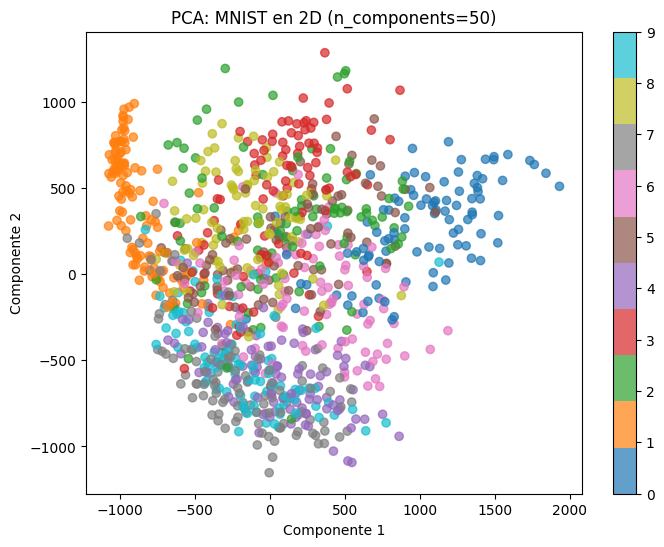

/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


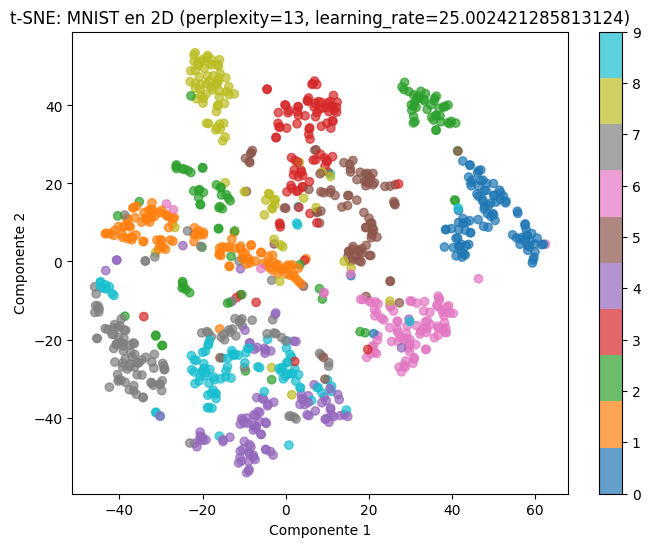

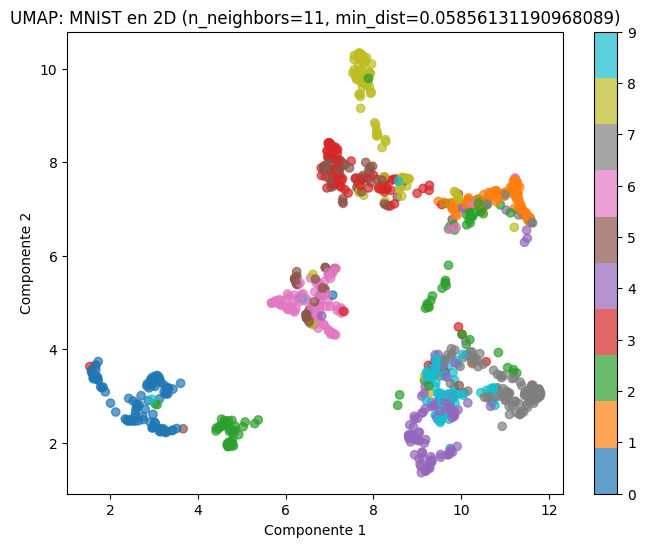

In [17]:
# 1. Visualización de PCA con los mejores hiperparámetros
best_n_components_pca = study_pca.best_params['n_components']
pca = PCA(n_components=best_n_components_pca)
X_pca = pca.fit_transform(X_train)
plot_embedding(X_pca, f"PCA: MNIST en 2D (n_components={best_n_components_pca})", y_train)

# 2. Visualización de t-SNE con los mejores hiperparámetros
best_n_components_tsne = study_tsne.best_params['n_components']
best_perplexity_tsne = study_tsne.best_params['perplexity']
best_learning_rate_tsne = study_tsne.best_params['learning_rate']
best_n_iter_tsne = study_tsne.best_params['n_iter']
tsne = TSNE(
    n_components=best_n_components_tsne,
    perplexity=best_perplexity_tsne,
    learning_rate=best_learning_rate_tsne,
    n_iter=best_n_iter_tsne
)
X_tsne = tsne.fit_transform(X_train)
plot_embedding(X_tsne, f"t-SNE: MNIST en 2D (perplexity={best_perplexity_tsne}, learning_rate={best_learning_rate_tsne})", y_train)

# 3. Visualización de UMAP con los mejores hiperparámetros
best_n_components_umap = study_umap.best_params['n_components']
best_n_neighbors_umap = study_umap.best_params['n_neighbors']
best_min_dist_umap = study_umap.best_params['min_dist']
umap_model = umap.UMAP(
    n_components=best_n_components_umap,
    n_neighbors=best_n_neighbors_umap,
    min_dist=best_min_dist_umap
)
X_umap = umap_model.fit_transform(X_train)
plot_embedding(X_umap, f"UMAP: MNIST en 2D (n_neighbors={best_n_neighbors_umap}, min_dist={best_min_dist_umap})", y_train)

In [12]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import optuna

# Función para optimizar PCA, t-SNE y UMAP usando Optuna
def objective(trial):
    method = trial.suggest_categorical("method", ["pca", "tsne", "umap"])

    if method == "pca":
        n_components = trial.suggest_int("n_components", 2, 50)
        pca = PCA(n_components=n_components)
        X_embedded = pca.fit_transform(X_train)

    elif method == "tsne":
        n_components = trial.suggest_int("n_components", 2, 3)
        perplexity = trial.suggest_int("perplexity", 5, 50)
        learning_rate = trial.suggest_loguniform("learning_rate", 10, 1000)
        n_iter = trial.suggest_int("n_iter", 250, 1000)
        tsne = TSNE(n_components=n_components, perplexity=perplexity, learning_rate=learning_rate, n_iter=n_iter)
        X_embedded = tsne.fit_transform(X_train)

    elif method == "umap":
        n_components = trial.suggest_int("n_components", 2, 3)
        n_neighbors = trial.suggest_int("n_neighbors", 5, 50)
        min_dist = trial.suggest_uniform("min_dist", 0.0, 0.99)
        umap_model = umap.UMAP(n_components=n_components, n_neighbors=n_neighbors, min_dist=min_dist)
        X_embedded = umap_model.fit_transform(X_train)

    # Entrenar un clasificador KNN en el espacio embebido para evaluar la calidad de la reducción de dimensionalidad
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_embedded, y_train)

    # Evaluar en el conjunto de prueba después de transformar los datos de prueba
    if method == "pca":
        X_test_embedded = pca.transform(X_test)
    elif method == "tsne":
        X_test_embedded = tsne.fit_transform(X_test)
    elif method == "umap":
        X_test_embedded = umap_model.transform(X_test)

    y_pred = knn.predict(X_test_embedded)
    accuracy = accuracy_score(y_test, y_pred)

    return accuracy



In [13]:
# Crear el estudio Optuna para optimización
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)  # Ajusta el número de pruebas si deseas más o menos iteraciones

# Mejor hiperparámetro encontrado
print("Best trial:")
trial = study.best_trial
print(f"  Value: {trial.value}")
print("  Params: ")
for key, value in trial.params.items():
    print(f"    {key}: {value}")




[I 2024-10-29 18:44:04,710] A new study created in memory with name: no-name-e9baac09-2b05-4ab2-bf09-94db88a94225
<ipython-input-12-51e76f93b531>:26: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  min_dist = trial.suggest_uniform("min_dist", 0.0, 0.99)
[I 2024-10-29 18:44:20,366] Trial 0 finished with value: 0.657 and parameters: {'method': 'umap', 'n_components': 2, 'n_neighbors': 14, 'min_dist': 0.3606214527769272}. Best is trial 0 with value: 0.657.
<ipython-input-12-51e76f93b531>:26: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  min_dist = trial.suggest_uniform("min_dist", 0.0, 0.99)
[I 2024-10-29 18:44:25,561] Trial 1 finished with value: 0.657 and parameters: {'method': 'umap', 'n_components': 2, 'n_

Best trial:
  Value: 0.864
  Params: 
    method: pca
    n_components: 22


In [14]:
import numpy as np

# Visualizar el mejor resultado encontrado
def plot_best_result():
    best_method = trial.params["method"]
    print(f"Best method: {best_method}")

    if best_method == "pca":
        n_components = trial.params["n_components"]
        pca = PCA(n_components=n_components)
        X_best = pca.fit_transform(np.concatenate([X_train, X_test]))
        title = f"PCA with n_components={n_components}"

    elif best_method == "tsne":
        n_components = trial.params["n_components"]
        perplexity = trial.params["perplexity"]
        learning_rate = trial.params["learning_rate"]
        n_iter = trial.params["n_iter"]
        tsne = TSNE(n_components=n_components, perplexity=perplexity, learning_rate=learning_rate, n_iter=n_iter)
        X_best = tsne.fit_transform(np.concatenate([X_train, X_test]))
        title = f"t-SNE with perplexity={perplexity}, learning_rate={learning_rate}"

    elif best_method == "umap":
        n_components = trial.params["n_components"]
        n_neighbors = trial.params["n_neighbors"]
        min_dist = trial.params["min_dist"]
        umap_model = umap.UMAP(n_components=n_components, n_neighbors=n_neighbors, min_dist=min_dist)
        X_best = umap_model.fit_transform(np.concatenate([X_train, X_test]))
        title = f"UMAP with n_neighbors={n_neighbors}, min_dist={min_dist}"

    # Visualizar el resultado
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(X_best[:, 0], X_best[:, 1], c=np.concatenate([y_train, y_test]), cmap='tab10', alpha=0.7)
    plt.colorbar(scatter, ticks=range(10))
    plt.title(title)
    plt.xlabel("Componente 1")
    plt.ylabel("Componente 2")
    plt.show()



Best method: pca


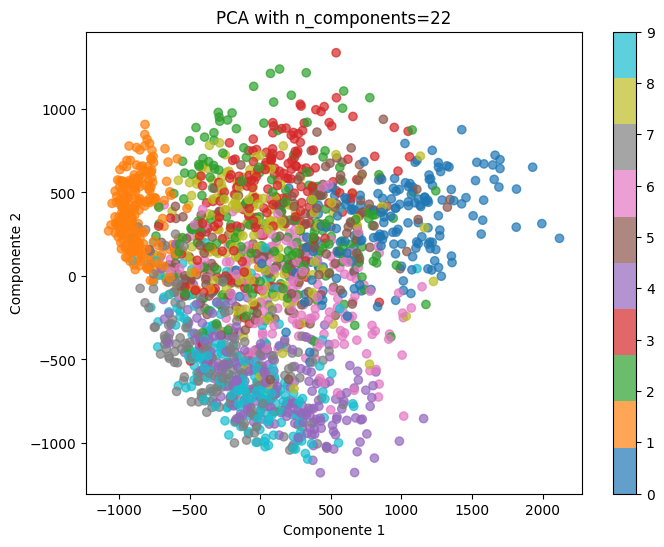

In [15]:
# Llamar a la función de visualización del mejor resultado
plot_best_result()